# **ThermoModel v2: Bands That Account for Diminishing Returns**

The goal is unchanged: a corridor whose upper edge marks cycle tops and whose lower edge marks cycle bottoms. What changes is how the bands are built, because the original model has two structural problems that show up exactly where it hurts - predicting tops.

## What was wrong

The original ThermoModel fits a **cubic polynomial in day index** to log price, then adds **fixed offsets in log space** for the bands.

1. A cubic in raw time extrapolates explosively upward. That is the *opposite* of diminishing returns, and it is why the upper band runs away: run out-of-sample on the 2020-2025 cycle, the original approach projected a top near **$495,000** against an actual **$125,000**.
2. A fixed offset in log space means the band keeps a constant multiplicative width forever. If cycle amplitude is compressing, no fixed offset can track it - too wide late, or too narrow early. In 2017 the same approach put the upper band *below* the actual top (-39%), so price simply broke through it.

## The trend: a power law whose exponent eases off

The backbone is a log-log trend, with `L = log10(days since genesis)`:

    log10(price) = a + b·L + c·L²

A plain power law (`c = 0`) has one fixed exponent. Refitted in real time, that exponent has kept falling - 6.8 at the 2015 bottom, 5.9 at 2018, 5.8 at 2022, 5.6 today - so every fit projected the next cycle too high: forecast from the previous bottom, it overshot the 2018, 2022 and 2026 bottoms by +130%, +44% and +30%. The quadratic term builds that decline in: the exponent eases from about 5.8 in 2014 to 5.4 in 2018 and 4.9 today (4.4 by 2045; it never reaches zero on any horizon that matters). The trend grows ~31% a year today and ~25% by 2030, against 36% and 30% for the fixed exponent.

On the two cycles with enough history behind the fit, the concave trend forecast the next bottom four years ahead at -7% and +9%, and - through v2's upper band - the next top at -1% and +13%, where the fixed exponent overshot by +22% and +44% (see `backtest_trend()` and the validation below). It does need that history: fitted before 2018, on under eight years of data, it is unstable. In-sample the two fits are all but identical (R² 0.963 vs 0.962). `load_dataframe(concave_trend=False)` restores the plain power law.

## What the data actually says

Measured against that trend, the cycle extremes are:

| Cycle top | multiple of trend | | Cycle bottom | multiple of trend |
|---|---|---|---|---|
| 2011-06 | 18.4x | | 2011-11 | 0.46x |
| 2013-12 | 9.7x | | 2015-01 | 0.46x |
| 2017-12 | 5.7x | | 2018-12 | 0.54x |
| 2021-11 | 3.0x | | 2022-11 | 0.47x |
| 2025-10 | 1.4x | | 2026-07 | 0.56x |

**Tops compress hard. Bottoms do not.** That asymmetry is the whole point, and the original model misses it by treating both bands the same way.

## The v2 construction

    upper(t) = trend(t) + max(a + b·cycle_position(t), upper_floor)
    lower(t) = trend(t) + mean(bottom residuals)

The upper offset decays linearly in cycle position (fitted on the five observed tops); the lower one is a constant, because that is what five observed bottoms support. The floor stops the decaying band from extrapolating *below* the trend, which would be nonsense. At its default of 0 it binds on no historical cycle, so it costs nothing in backtest.

## Validation

Leave-future-out, on the task the model exists for: for each cycle top, refit the trend and the decay on data and cycles strictly *before* it, then compare the predicted upper band against the price actually reached. The original fixed-offset approach, and v2 on a fixed-exponent power law, go through the identical test as baselines.

**Result: median absolute error 13% (v2) vs 22% (v2 on a fixed-exponent power law) vs 83% (original).** On the 2021 and 2025 tops v2 lands at -1% and +13%, where the fixed exponent overshot by +22% and +44% and the original by +83% and ~4x. The one large miss is 2017 (-79%): refitted on data up to mid-2017, only seven years of it, the concave trend bends too early - the same short-history instability the bottom backtest shows.

## The honest limitation

The fitted decay is steep enough that the upper band settles onto its asymptote - close to the trend - from around early 2028. The decay bends into that asymptote smoothly (a softplus rather than a hard clamp, which would put a visible kink in the band on the day the two met and a dead flat line after it). That is the faithful reading of five data points, but five is not many, and "future tops sit near the trend line" is an aggressive claim. `upper_floor` is exposed so the band can be given a positive asymptote instead (0.1 → tops at least 1.26x trend, 0.2 → 1.58x). Raising it changes no historical band, only the extrapolation.

*Not financial advice.*


In [1]:
import sys
import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_ThermoModel2 import (
    load_dataframe,
    plot_thermomodel,
    validate_top_prediction,
    backtest_trend,
    project_next_top,
)
import warnings
warnings.filterwarnings("ignore")

df, params = load_dataframe()

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23


## The bands

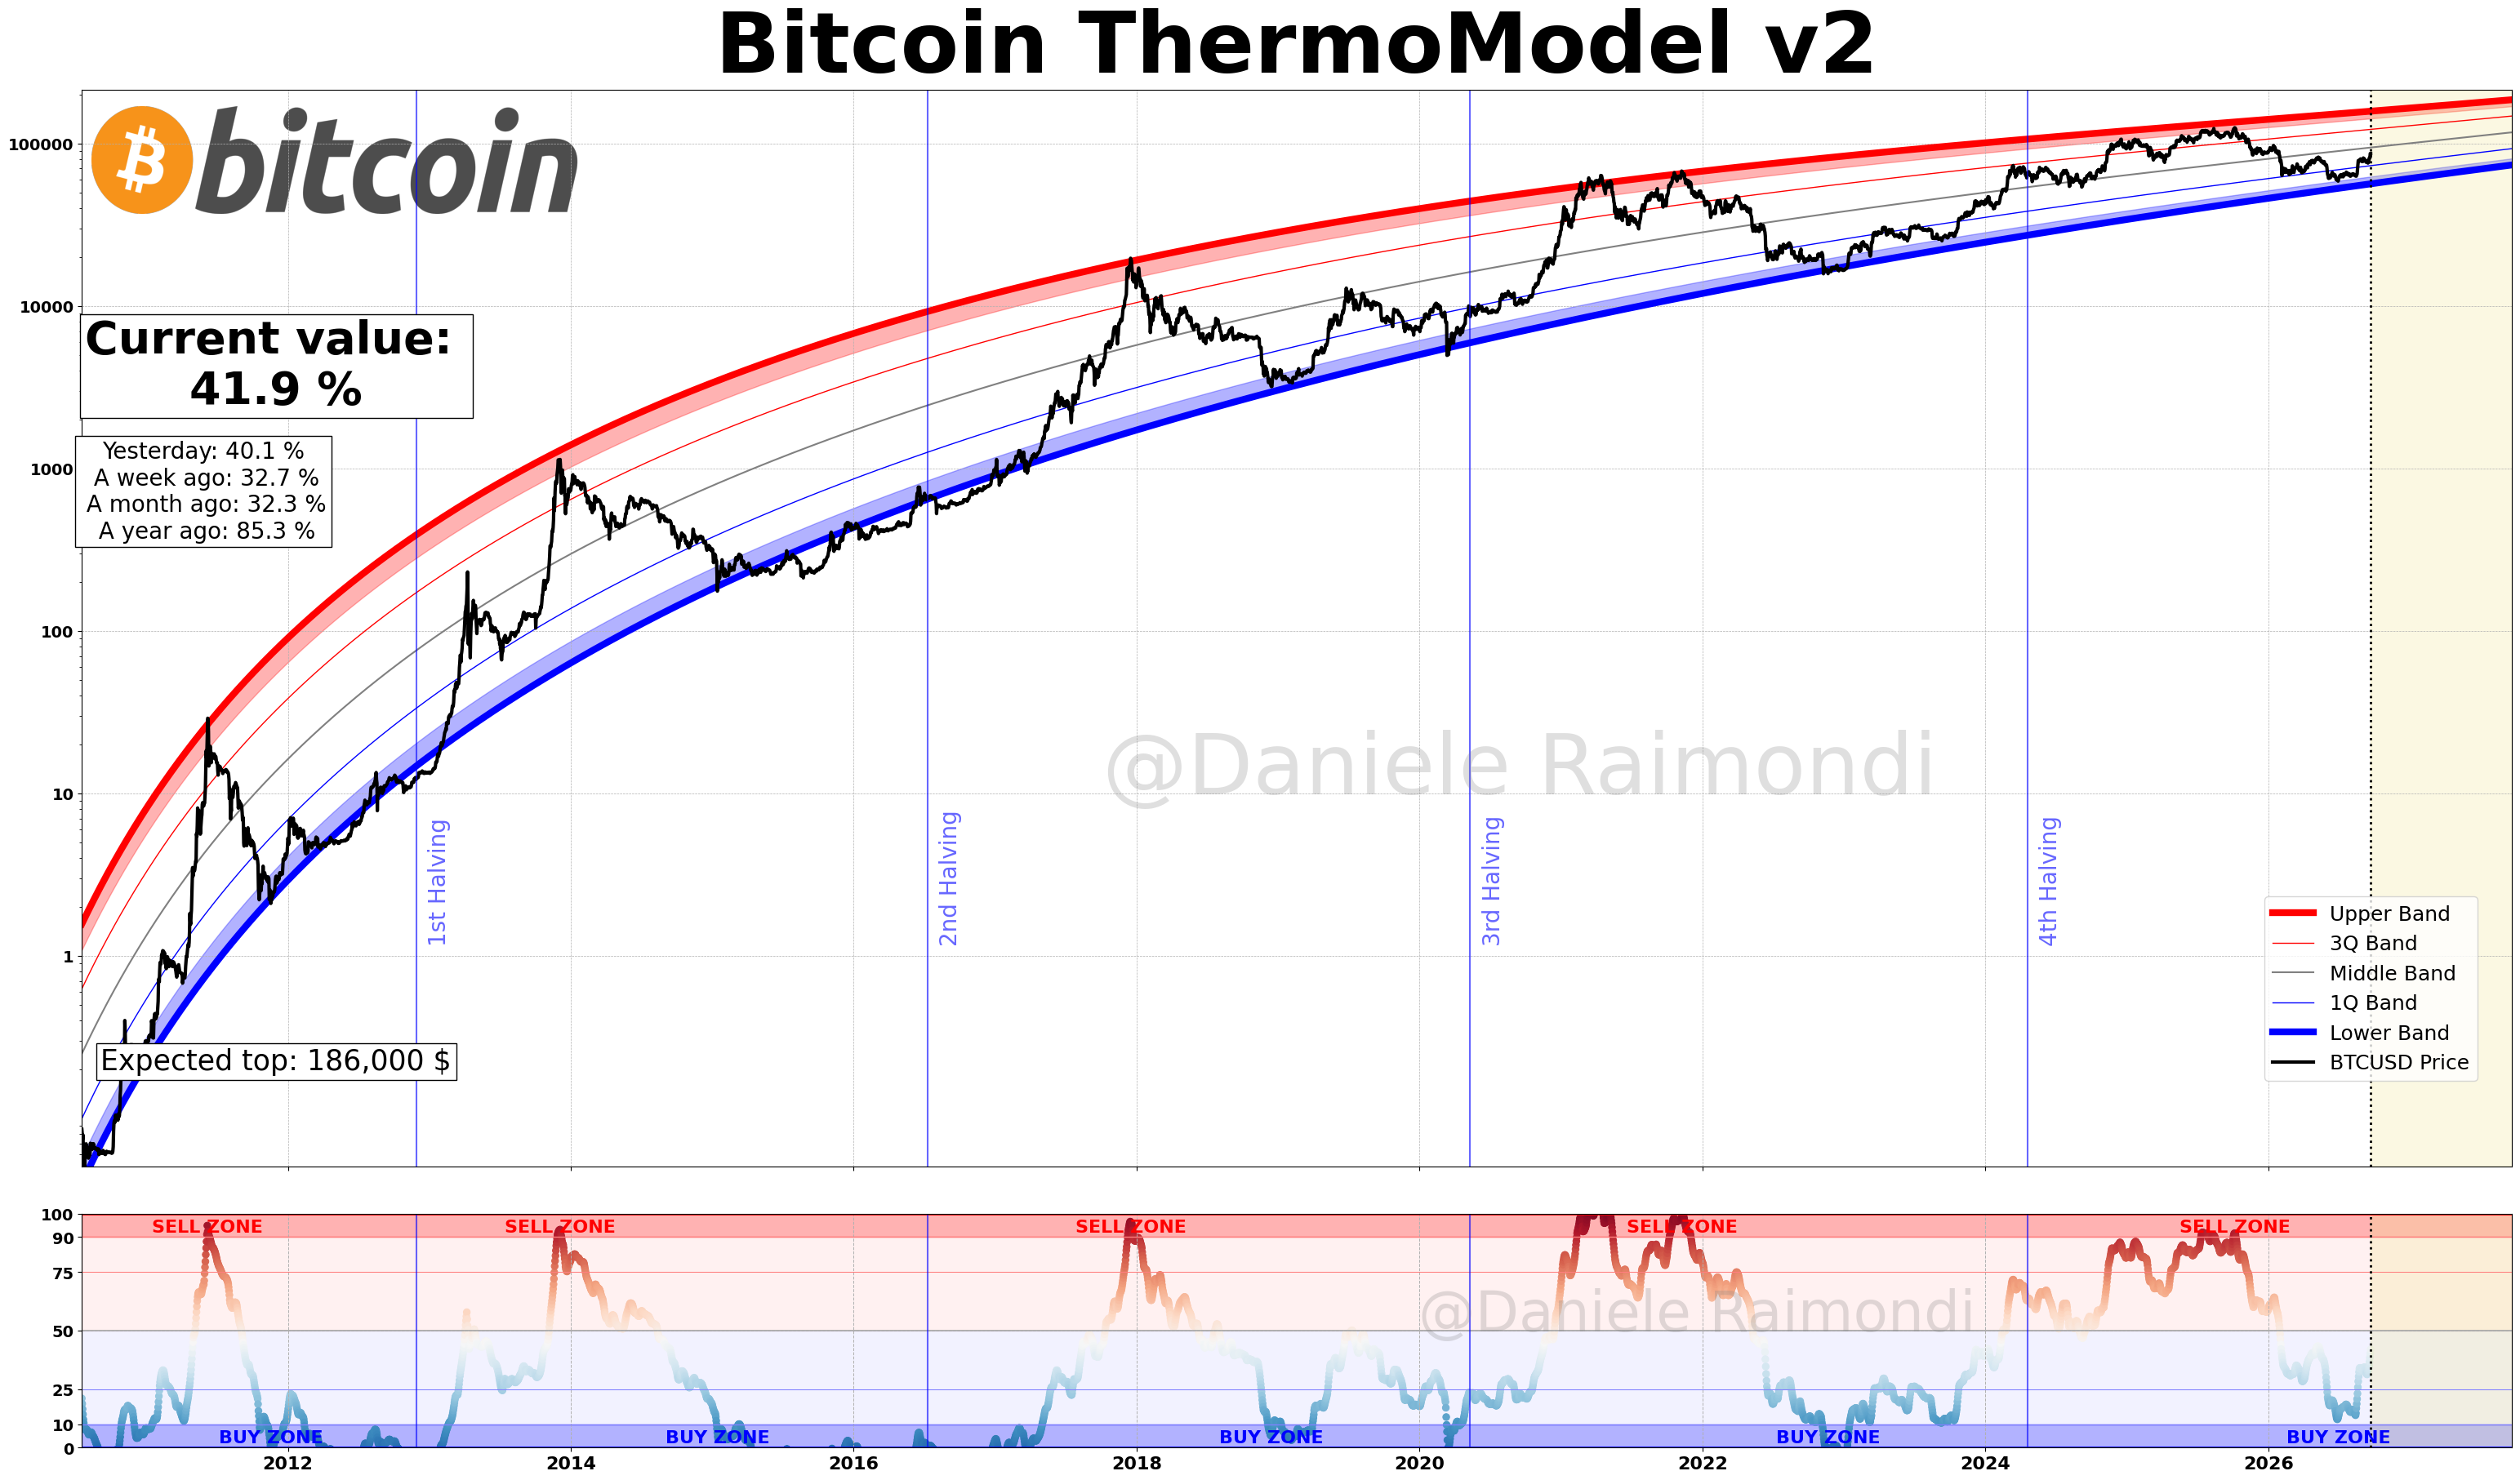

Trend: log10(price) = -25.877 +11.338*L -0.8455*L^2,  L = log10(days since genesis)   R2 = 0.963
Local exponent today: 4.89
Top multiples vs trend, cycle by cycle: [18.43, 9.71, 5.69, 2.96, 1.45] (compressing)
Bottom multiples vs trend:              [0.46, 0.46, 0.54, 0.47, 0.56] (flat)

Today (2026-09-22): price $86,613  band $56,364 - $157,682
Position in band: 41.9% smoothed (41.8% raw) - the chart's readout box and the oscillator panel both show the smoothed value, as the original does.
In one year (2027-09-22): band $73,648 - $185,532   corridor midpoint $116,893


In [2]:
plot_thermomodel(df, params)

## Validation: out-of-sample top prediction, v2 vs the original

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23
Leave-future-out cycle top prediction

 cycle top  actual  v2 predicted  v2 error %  v2 power law predicted  v2 power law error %  v1 predicted  v1 error %
2017-12-17  19,250         3,981         -79                  20,687                     8        11,726         -39
2021-11-09  67,096        66,546          -1                  81,975                    22       122,557          83
2025-10-06 124,824       141,449          13                 179,498                    44       494,811         296

Median |error|:  v2 (concave trend) 13.3%   v2 (power-law trend) 22.2%   v1 (fixed offset) 82.7%


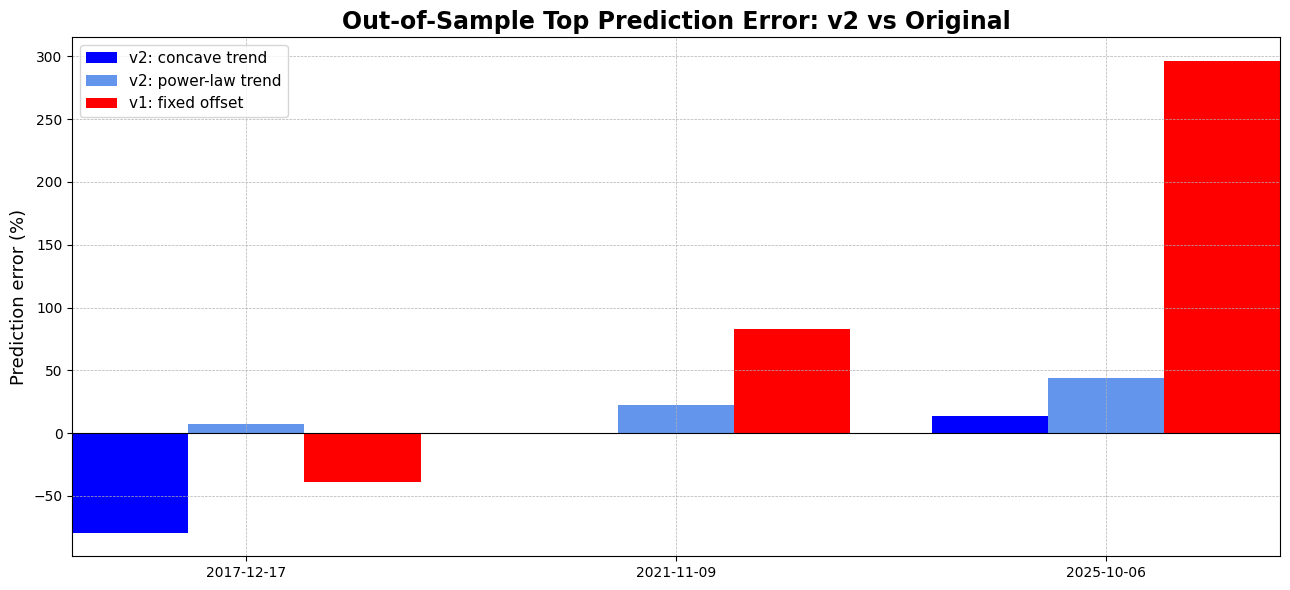

In [3]:
validation = validate_top_prediction(df)

## Why the trend is concave: every bottom, forecast in real time

Each cycle bottom forecast with only the data available at the time, from the previous bottom (about four years ahead, where the model stands today) and from the top before it (about one year ahead). The lower band is the trend times the mean bottom multiple so far, as in `load_dataframe`.

In [4]:
trend_backtest = backtest_trend()

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23
Real-time forecasts of each cycle bottom from the lower band

    bottom                                   forecast actual  power law error % power law exponent  concave error % concave exponent
2018-12-15 ~4y, from the previous bottom (2015-01-14)  3,185              130.4               6.82            285.6             7.43
2018-12-15      ~1y, from the top before (2017-12-17)  3,185              -12.9               5.70            -57.2             3.98
2022-11-21 ~4y, from the previous bottom (2018-12-15) 15,778               44.4               5.88             -6.8             5.17
2022-11-21      ~1y, from the top before (2021-11-09) 15,778               43.7               5.87             31.0             5.63
2026-07-01 ~4y, from the previous bottom (2022-11-21) 60,004               29.7               5.84              8.7             5.49
202

## Where does this put the next cycle top?

In [5]:
project_next_top(df, params)

Decay of the top multiple: offset = 1.408 -0.296 * cycle_position  (floored at 0.00)

Implied cycle top if it lands on:
  Oct 2028:  trend $   191,622   upper band $    221,282   (offset +0.063 = 1.15x trend) (near the asymptote)
  Oct 2029:  trend $   242,833   upper band $    265,239   (offset +0.038 = 1.09x trend) (near the asymptote)
  Oct 2030:  trend $   303,813   upper band $    320,066   (offset +0.023 = 1.05x trend) (near the asymptote)

Read this with care. By the next cycle the linear decay has run below its asymptote,
so the band is settling onto `upper_floor` rather than still tracking the decay -
these figures are driven mostly by the trend extrapolation, and the decay itself
rests on five observations. Raise `upper_floor` in load_dataframe() for a less
aggressive assumption about how far tops keep compressing.


## A less aggressive assumption

The same model with a positive asymptote on the upper band, so that future tops are not assumed to converge all the way onto the trend line. Historical bands are identical; only the extrapolation moves.

In [6]:
df_soft, params_soft = load_dataframe(upper_floor=0.15)
project_next_top(df_soft, params_soft)

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)
🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23


Decay of the top multiple: offset = 1.408 -0.296 * cycle_position  (floored at 0.15)

Implied cycle top if it lands on:
  Oct 2028:  trend $   191,622   upper band $    284,941   (offset +0.172 = 1.49x trend) (near the asymptote)
  Oct 2029:  trend $   242,833   upper band $    353,294   (offset +0.163 = 1.45x trend) (near the asymptote)
  Oct 2030:  trend $   303,813   upper band $    436,380   (offset +0.157 = 1.44x trend) (near the asymptote)

Read this with care. By the next cycle the linear decay has run below its asymptote,
so the band is settling onto `upper_floor` rather than still tracking the decay -
these figures are driven mostly by the trend extrapolation, and the decay itself
rests on five observations. Raise `upper_floor` in load_dataframe() for a less
aggressive assumption about how far tops keep compressing.


## Timing

The bands say *how high and how low*, not *when*. The ThermoClock, which combines them with the cycle timing from `2a.Cycles` into a dated price path, lives in its own notebook: `1j.ThermoClock`.